<a href="https://colab.research.google.com/github/aadarshmishra0709-web/bank-churn-model.ml/blob/main/BARCLAYS_CUSTOMER_CHURN_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project Objective
- Barclays Bank Facing hing Customer churnrate, abd customer not keep using services, being a data scitentist your task is to identify the conpanies problem so that they can get the real time insisghts and management can take decision accordingly, Previously banks were not getting timely insights and did not take decison timely, costs high coustomer churn rate, the previous methedologies were old and not upto dated, presently bank needs live analysis and corrective measures to predict the future churn rates and live analysis.


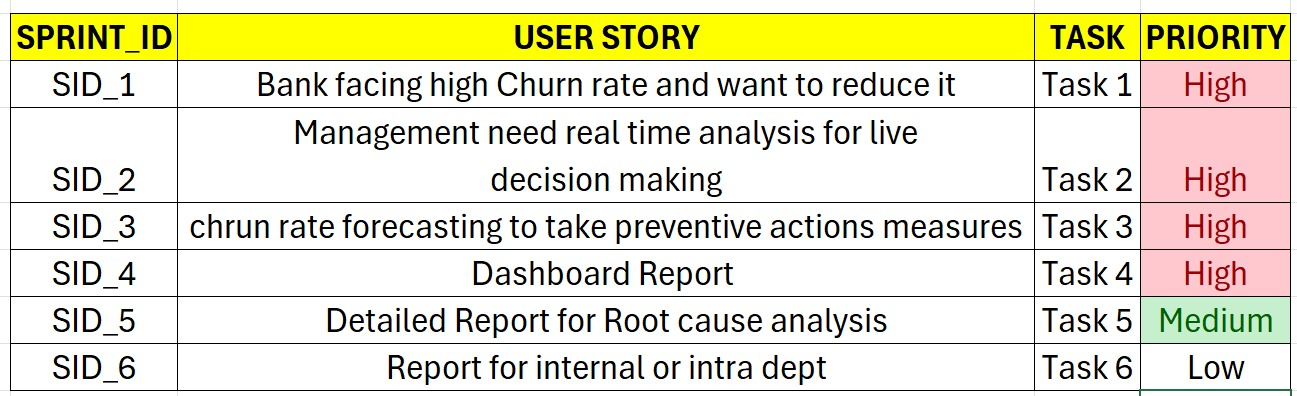

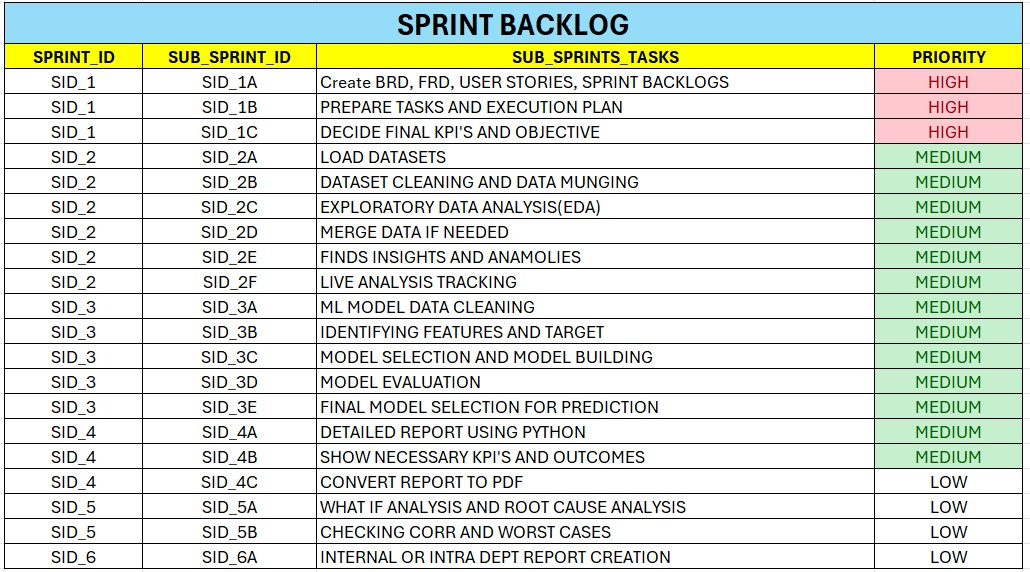

STEP 1: LOAD IMPORT MODULES


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score
import pickle
import IPython as ip
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')
print("All Modules Loaded Successfully!!")



All Modules Loaded Successfully!!


In [46]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/ActiveCustomer.xlsx"
active_customer_df= pd.read_excel(url)
print("done")

done


In [47]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/CreditCard.xlsx"
credit_card_df=pd.read_excel(url)
print("done")

done


In [48]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/ExitCustomer.xlsx"
exit_customer_df=pd.read_excel(url)
print("done")

done


In [49]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/Gender.xlsx"
gender_df=pd.read_excel(url)
print("done")

done


In [50]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/Geography.xlsx"
geography_df=pd.read_excel(url)
print("done")

done


In [51]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/Bank_Churn.csv"
bank_churn_df=pd.read_csv(url)
print("done")

done


In [52]:
url="https://github.com/aadarshmishra0709-web/bank-churn-model.ml/raw/refs/heads/main/CustomerInfo.csv"
customer_info_df=pd.read_csv(url)
print("done")

done


In [53]:
all_dfs=[active_customer_df,credit_card_df,exit_customer_df,gender_df,geography_df,bank_churn_df,customer_info_df]
for i in all_dfs:
  print('='*50)
  display(i.sample(2))

,ActiveID,ActiveCategory
0,1,Active Member
1,0,Inactive Member


,CreditID,Category
1,0,non credit card holder
0,1,credit card holder


,ExitID,ExitCategory
0,1,Exit
1,0,Retain


,GenderID,GenderCategory
1,2,Female
0,1,Male


,GeographyID,GeographyLocation
0,1,France
2,3,Germany


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
9147,9148,15781326,636,1,1,35,6,95478.17,1,0,0,169286.74,0,10-04-2017
718,719,15696859,474,1,1,45,4,0.00,2,0,0,172175.90,0,11-11-2018


,CustomerId,Surname
660,15592937,Napolitani
9779,15712568,Angelo


In [54]:
# Step3.1:Show df shape size
bank_churn_df.shape



(10000, 14)

In [55]:
bank_churn_df.size

140000

In [56]:
#combine all dfs
merged_df=pd.merge(bank_churn_df,customer_info_df,on='CustomerId')
merged_df=pd.merge(merged_df,geography_df,on='GeographyID')
final_df=pd.merge(merged_df,gender_df,on='GenderID')
final_df


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory
0,1,15634602,619,1,2,42,7,0.00,1,1,1,101348.88,1,23-03-2016,Hargrave,France,Female
1,2,15647311,608,2,2,41,4,83807.86,1,0,1,112542.58,0,09-10-2018,Hill,Spain,Female
2,3,15619304,502,1,2,42,4,159660.80,3,1,0,113931.57,1,25-03-2019,Onio,France,Female
3,4,15701354,699,1,2,39,3,0.00,2,0,0,93826.63,0,24-10-2019,Boni,France,Female
4,5,15737888,850,2,2,43,3,125510.82,1,1,1,79084.10,0,22-11-2019,Mitchell,Spain,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,1,1,39,5,0.00,2,1,0,96270.64,0,25-03-2018,Obijiaku,France,Male
9996,9997,15569892,516,1,1,35,5,57369.61,1,1,1,101699.77,0,17-06-2018,Johnstone,France,Male
9997,9998,15584532,709,1,2,36,5,0.00,1,0,1,42085.58,1,18-03-2018,Liu,France,Female
9998,9999,15682355,772,3,1,42,3,75075.31,2,1,0,92888.52,1,12-11-2019,Sabbatini,Germany,Male


In [57]:
#Step 3.4: Show Coloumn info
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   CreditScore        10000 non-null  int64  
 3   GeographyID        10000 non-null  int64  
 4   GenderID           10000 non-null  int64  
 5   Age                10000 non-null  int64  
 6   Tenure             10000 non-null  int64  
 7   Balance            10000 non-null  float64
 8   NumOfProducts      10000 non-null  int64  
 9   HasCrCard          10000 non-null  int64  
 10  IsActiveMember     10000 non-null  int64  
 11  EstimatedSalary    10000 non-null  float64
 12  Exited             10000 non-null  int64  
 13  Bank DOJ           10000 non-null  object 
 14  Surname            10000 non-null  object 
 15  GeographyLocation  10000 non-null  object 
 16  GenderCategory     1000

In [58]:
#Step 3.5: Drop Nan or Missing values
final_df.dropna(inplace=True)
print("Done")

Done


In [59]:
#step 3.6 show data stats
final_df.describe(include = 'number')

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,1.749500,1.454300,38.921800,4.86430,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,0.830433,0.497932,10.487806,1.21525,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,1.000000,1.000000,18.000000,3.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,1.000000,1.000000,32.000000,4.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,1.000000,1.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,3.000000,2.000000,44.000000,6.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,3.000000,2.000000,92.000000,7.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [60]:
#Step3.7: Show Categorical data stats
final_df.describe(include='object')


,Bank DOJ,Surname,GeographyLocation,GenderCategory
count,10000,10000,10000,10000
unique,1332,2932,3,2
top,16-12-2017,Smith,France,Male
freq,35,32,5014,5457


In [61]:
# 3.8: Show Data correlation
corr= final_df.corr(numeric_only=True)
corr
#corr range from
#-1 to +1
#-1 : represents: Highly -negative correlation
#+1 : represents: Highly +positive correlation
#0  : represents: No correlation

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,-0.005196,-0.018196,0.000783,0.002901,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.000821,0.002641,0.009497,0.003884,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,0.008267,0.002857,-0.003965,-0.007355,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
GeographyID,-0.005196,0.000821,0.008267,1.000000,0.016936,0.048092,-0.003858,0.348700,-0.006180,0.004036,-0.012692,0.007382,0.153771
GenderID,-0.018196,0.002641,0.002857,0.016936,1.000000,0.027544,-0.008018,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512
Age,0.000783,0.009497,-0.003965,0.048092,0.027544,1.000000,0.010788,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.002901,0.003884,-0.007355,-0.003858,-0.008018,0.010788,1.000000,0.001457,-0.029927,0.003857,-0.007576,0.005744,0.000699
Balance,-0.009067,-0.012419,0.006268,0.348700,-0.012087,0.028308,0.001457,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.006180,0.021859,-0.030680,-0.029927,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,0.004036,-0.005766,-0.011721,0.003857,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138


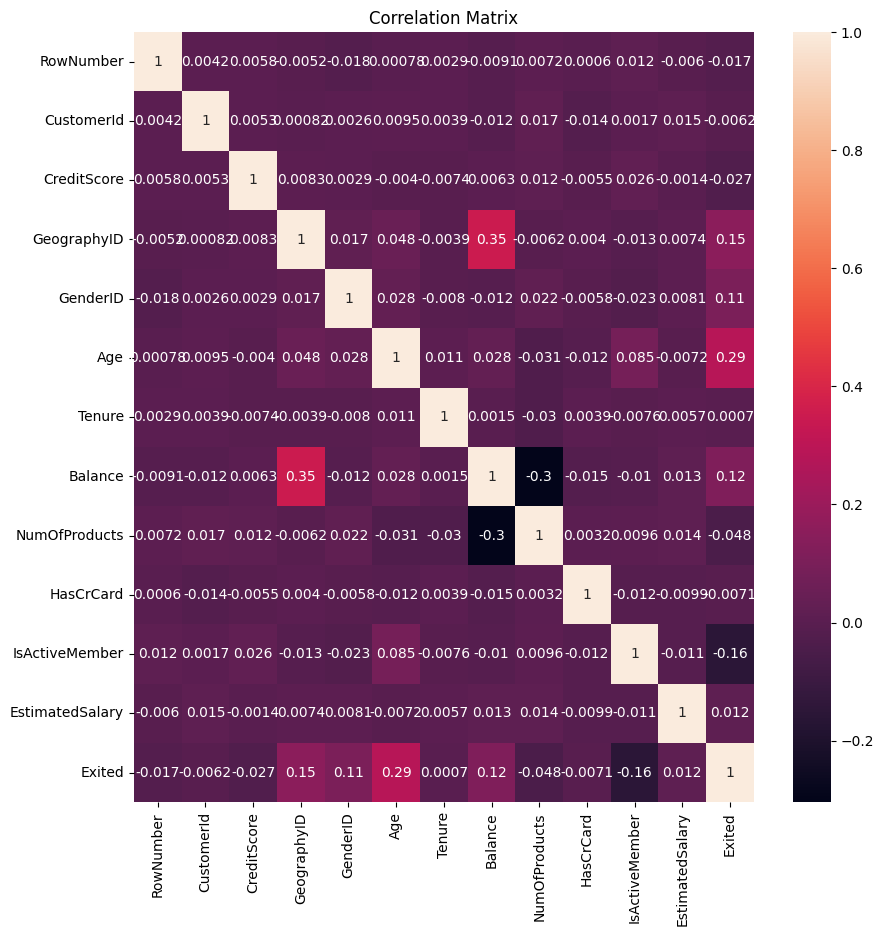

In [62]:
#Step 3.9
plt.figure(figsize=(10,10))
plt.title("Correlation Matrix")
sns.heatmap(corr,annot=True)
plt.show()

In [68]:
#Step 3.10 Divide Columns into require objects
textual_columns= final_df.select_dtypes('object').columns
numerical_columns= final_df.select_dtypes('number').columns
print("textual Columns:\n",textual_columns)
print('='*100)
print("numerical Columns:\n",numerical_columns)

textual Columns:
 Index(['Surname', 'GeographyLocation', 'GenderCategory'], dtype='object')
numerical Columns:
 Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')


In [64]:
#step 3.11: Change bank DOJ to datetime Dtype
final_df['Bank DOJ']=pd.to_datetime(final_df['Bank DOJ'])
print("Done")

Done


In [65]:
# Step 3.12: Drop unwanted column
final_df.drop('RowNumber', axis=1, inplace=True)
# axis=1 : means: drop column
# axis=0 : means: drop row
# inplace= True: means: apply cahnges in Original Dataset
print("Done")


Done


In [66]:
final_df.columns

Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Bank DOJ', 'Surname', 'GeographyLocation',
       'GenderCategory'],
      dtype='object')

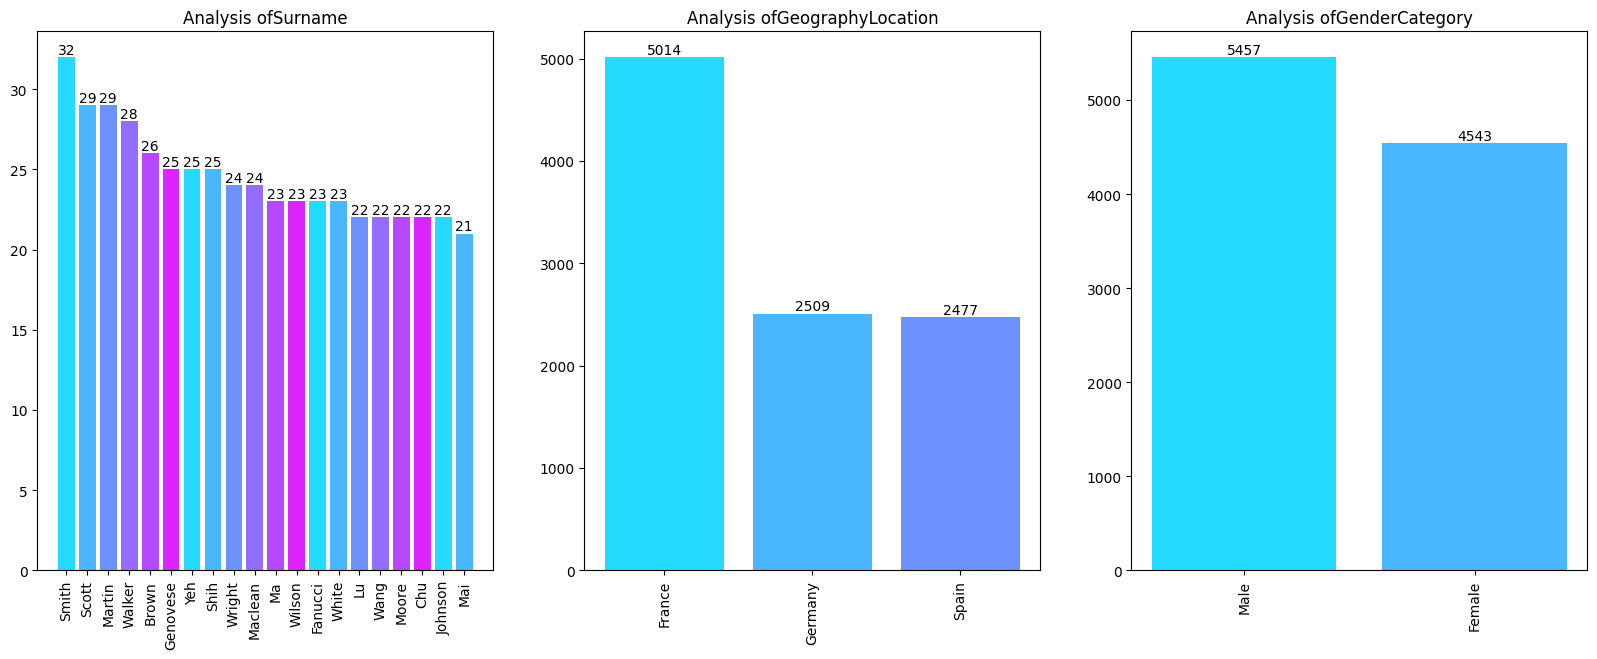

In [69]:
# Step 3.13: Univariate Analysis
# means: single columns analysis
plt.figure(figsize=(20,7))
for i,j in enumerate(textual_columns):
  plt.subplot(1,3,i+1)
  temp_df= final_df[j].value_counts().head(20)
  x= temp_df.index
  y= temp_df.values
  plt.title(f"Analysis of{j}")
  ax =plt.bar(x, y , color = sns.color_palette('cool'))
  plt.bar_label(ax)
  plt.xticks(rotation=90)
plt.show()
# plt.show: out of loop
# subplot: plot multiple plots at once
#i: is index
#j: is column name
# enumerate: to get index and value at same time
# value counts: to grouped data and count its value frequency
#sns.color_palette: to change color shades



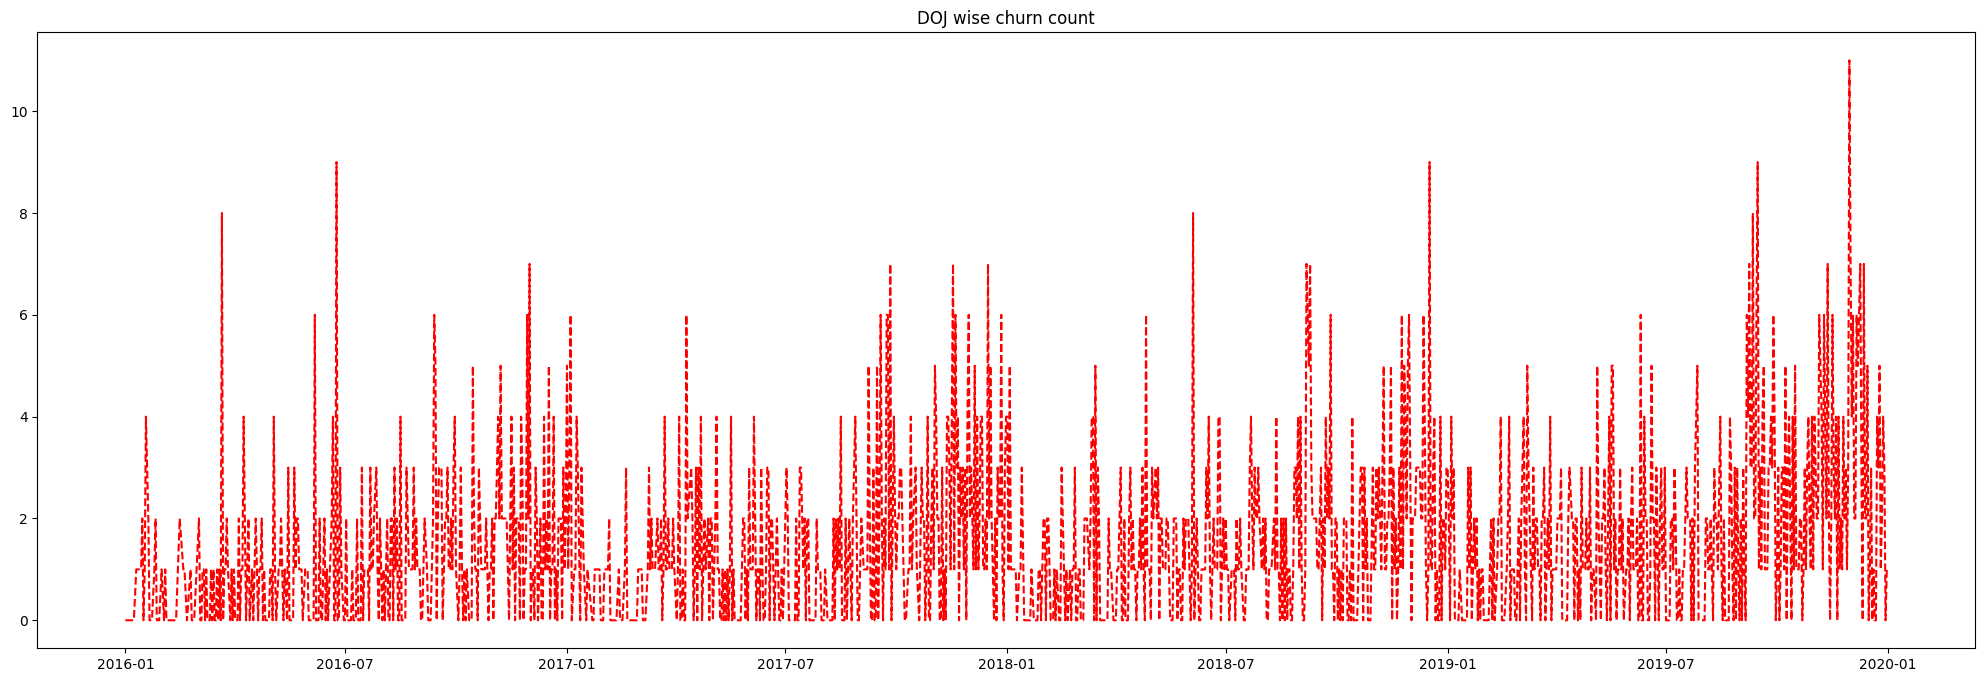

In [70]:
# Step 3.14: Bivariate Analysis
# Show Bank DOJ wise churn count'
plt.figure(figsize=(25,8))
plt.title("DOJ wise churn count")
temp_df= final_df.groupby('Bank DOJ')['Exited'].sum()
x= temp_df.index
y= temp_df.values
plt.plot(x,y, color='r', linestyle='--')
plt.show()



In [71]:
# Step 3.15: Create new column for monthly and weekly analysis
final_df['Month']= final_df['Bank DOJ'].dt.month_name()
final_df['Day']= final_df['Bank DOJ'].dt.day_name()

#.dt: means: datetime
final_df.sample()

,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
7148,15598802,770,2,1,30,5,0.0,2,0,1,50839.85,0,2018-06-25,Martin,Spain,Male,June,Monday


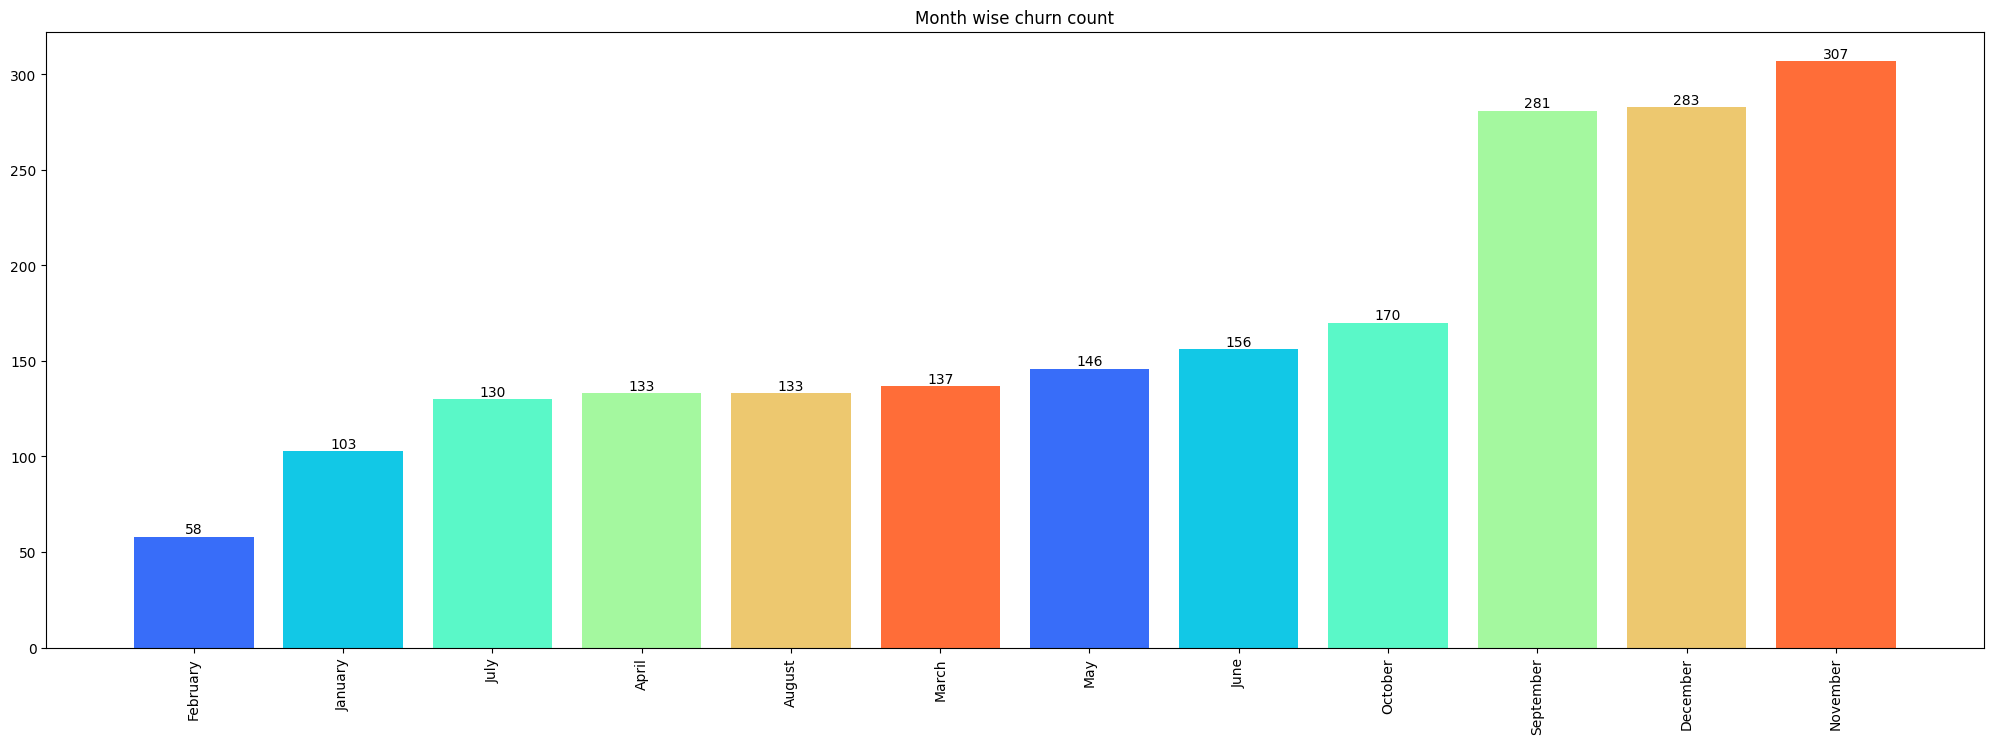

In [72]:
# Step 3.16: Show Monthly Churn Analysis
plt.figure(figsize=(25,8))
plt.title("Month wise churn count")
temp_df= final_df.groupby('Month')['Exited'].sum().sort_values()
x= temp_df.index
y= temp_df.values
ax =plt.bar(x, y , color = sns.color_palette('rainbow'))
plt.bar_label(ax)
plt.xticks(rotation=90)
plt.show()

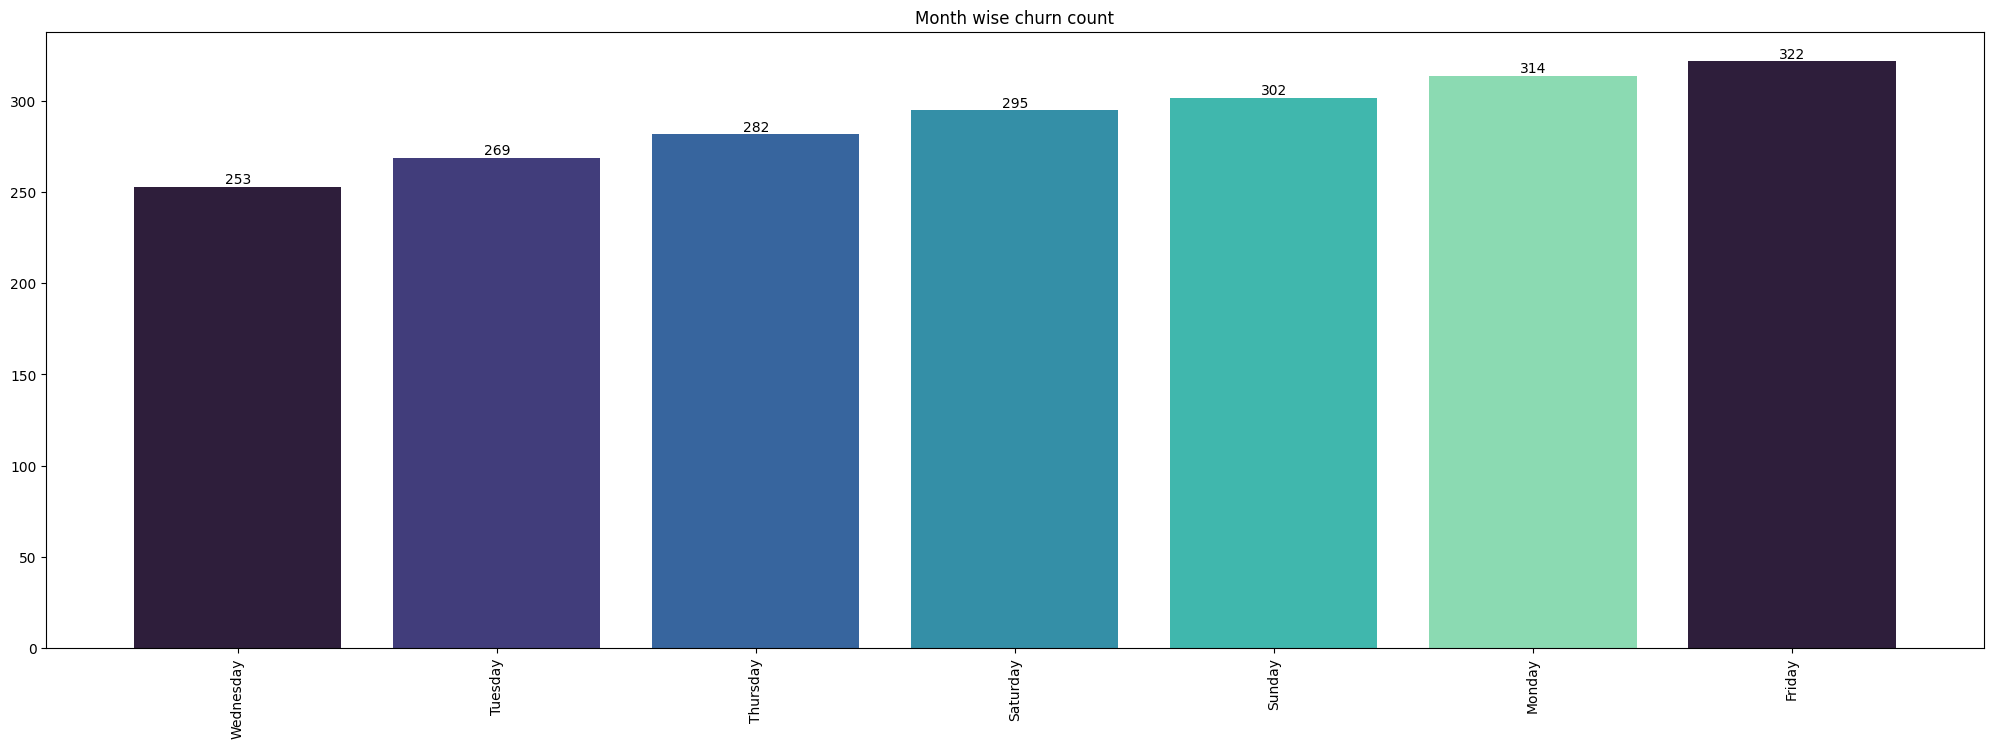

In [73]:
# Step 3.17: Show Day Wise Churn Analysis
plt.figure(figsize=(25,8))
plt.title("Month wise churn count")
temp_df= final_df.groupby('Day')['Exited'].sum().sort_values()
x= temp_df.index
y= temp_df.values
ax =plt.bar(x, y , color = sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation=90)
plt.show()

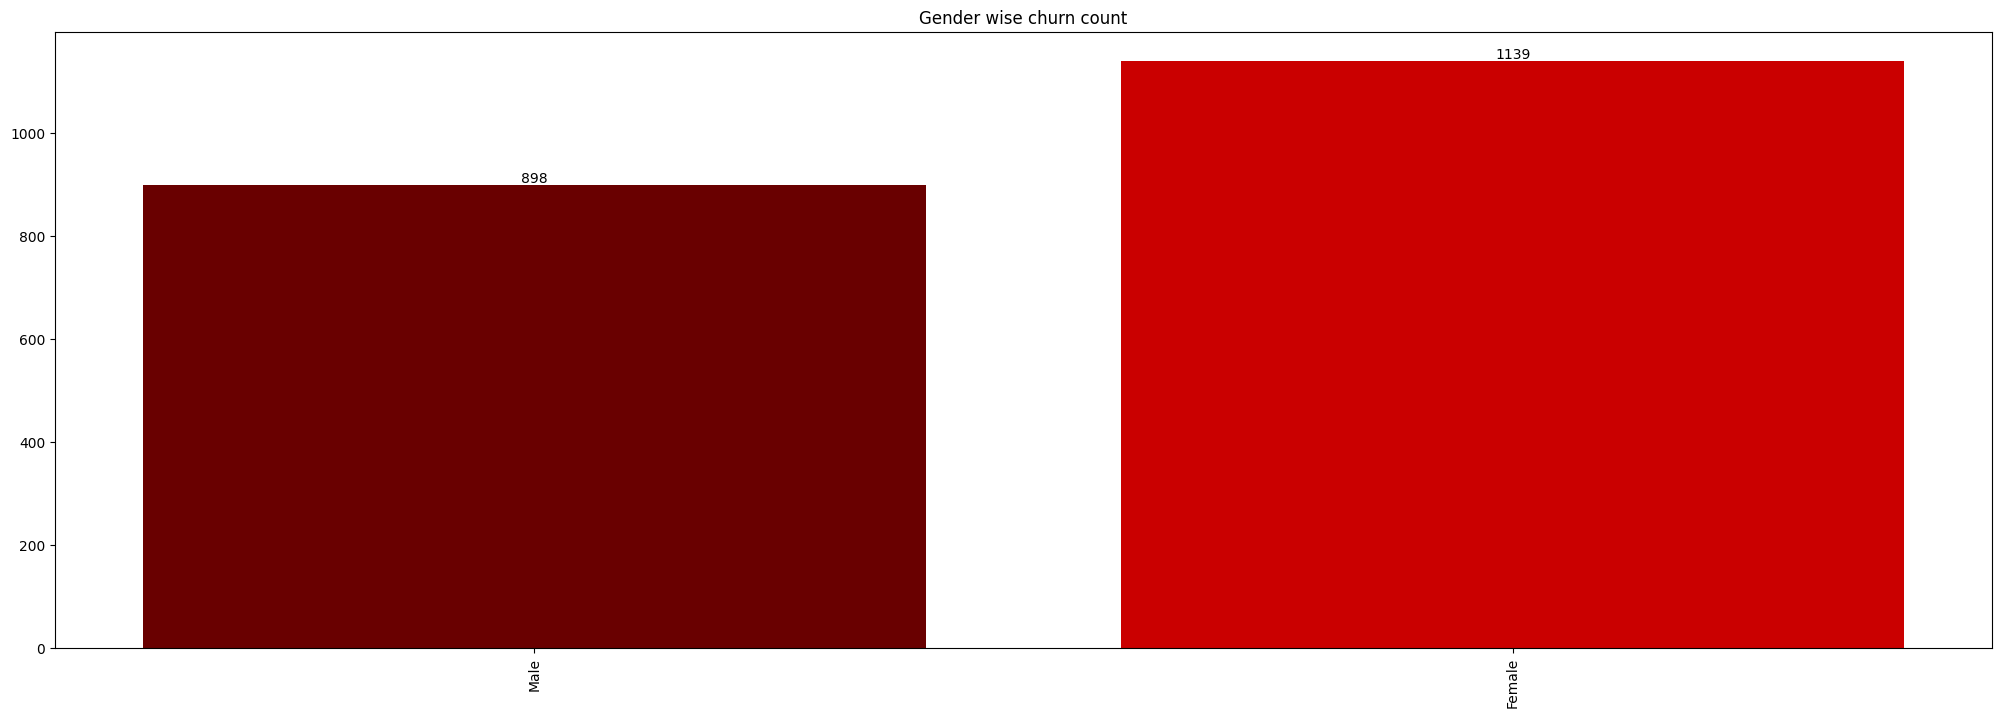

In [83]:
# Step 3.18: Show Gender Wise Churn Analysis
plt.figure(figsize=(25,8))
plt.title("Gender wise churn count")
temp_df= final_df.groupby('GenderCategory')['Exited'].sum().sort_values()
x= temp_df.index
y= temp_df.values
ax =plt.bar(x, y , color = sns.color_palette('hot'))
plt.bar_label(ax)
plt.xticks(rotation=90)
plt.show()


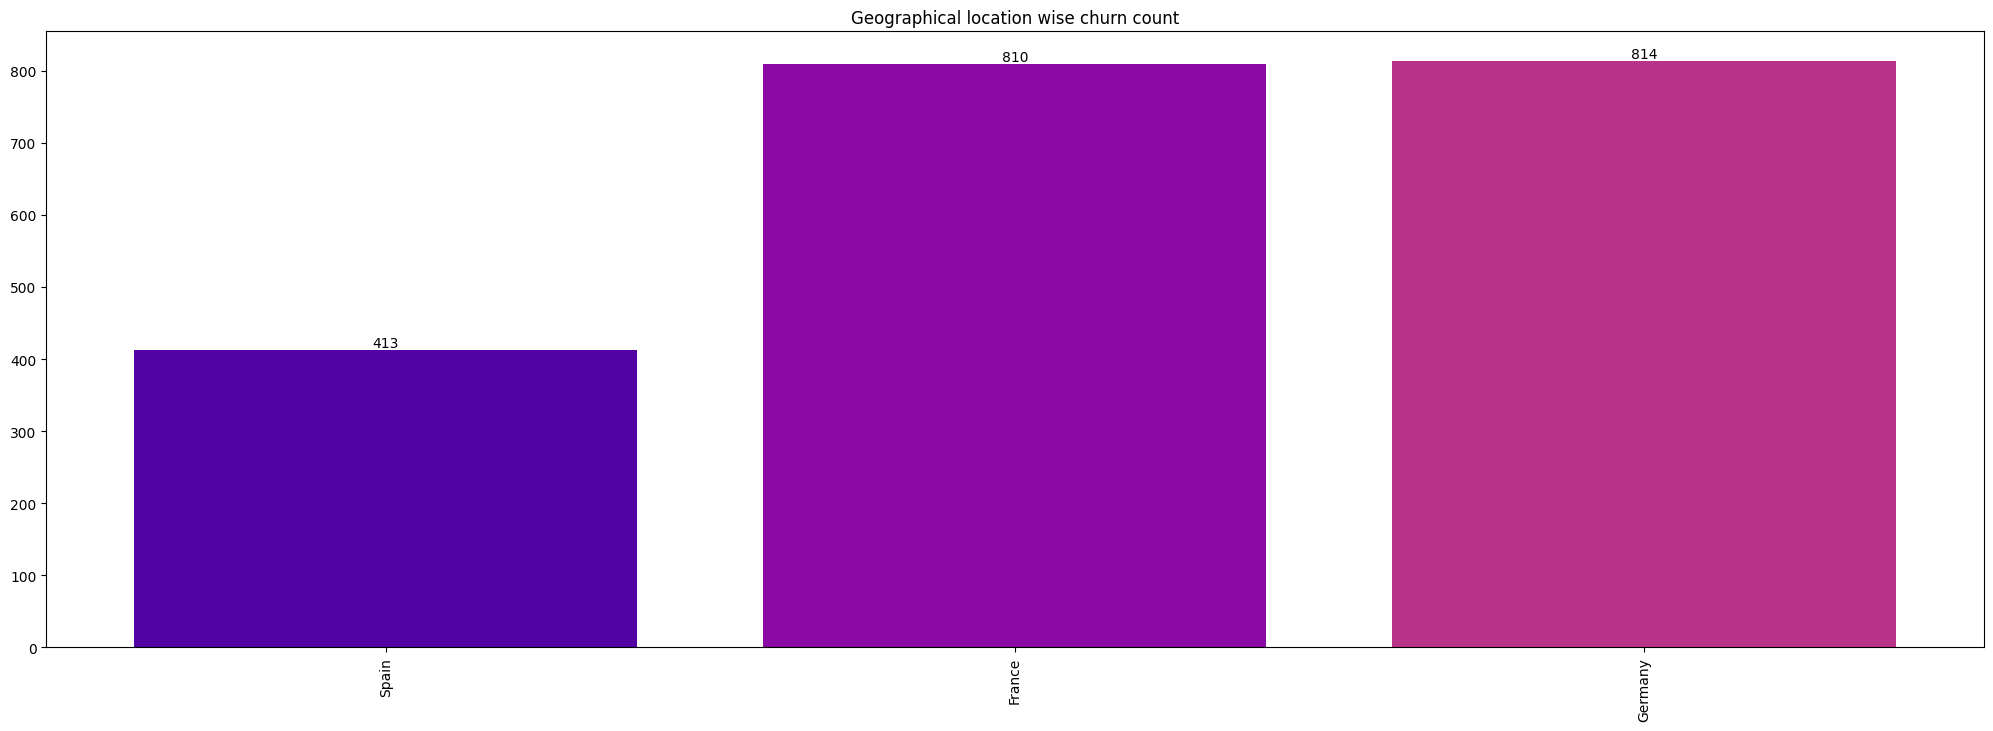

In [84]:
#Step 3.19: Show Geographical location Wise Churn Analysis
plt.figure(figsize=(25,8))
plt.title("Geographical location wise churn count")
temp_df= final_df.groupby('GeographyLocation')['Exited'].sum().sort_values()
x= temp_df.index
y= temp_df.values
ax =plt.bar(x, y , color = sns.color_palette('plasma'))
plt.bar_label(ax)
plt.xticks(rotation=90)
plt.show()


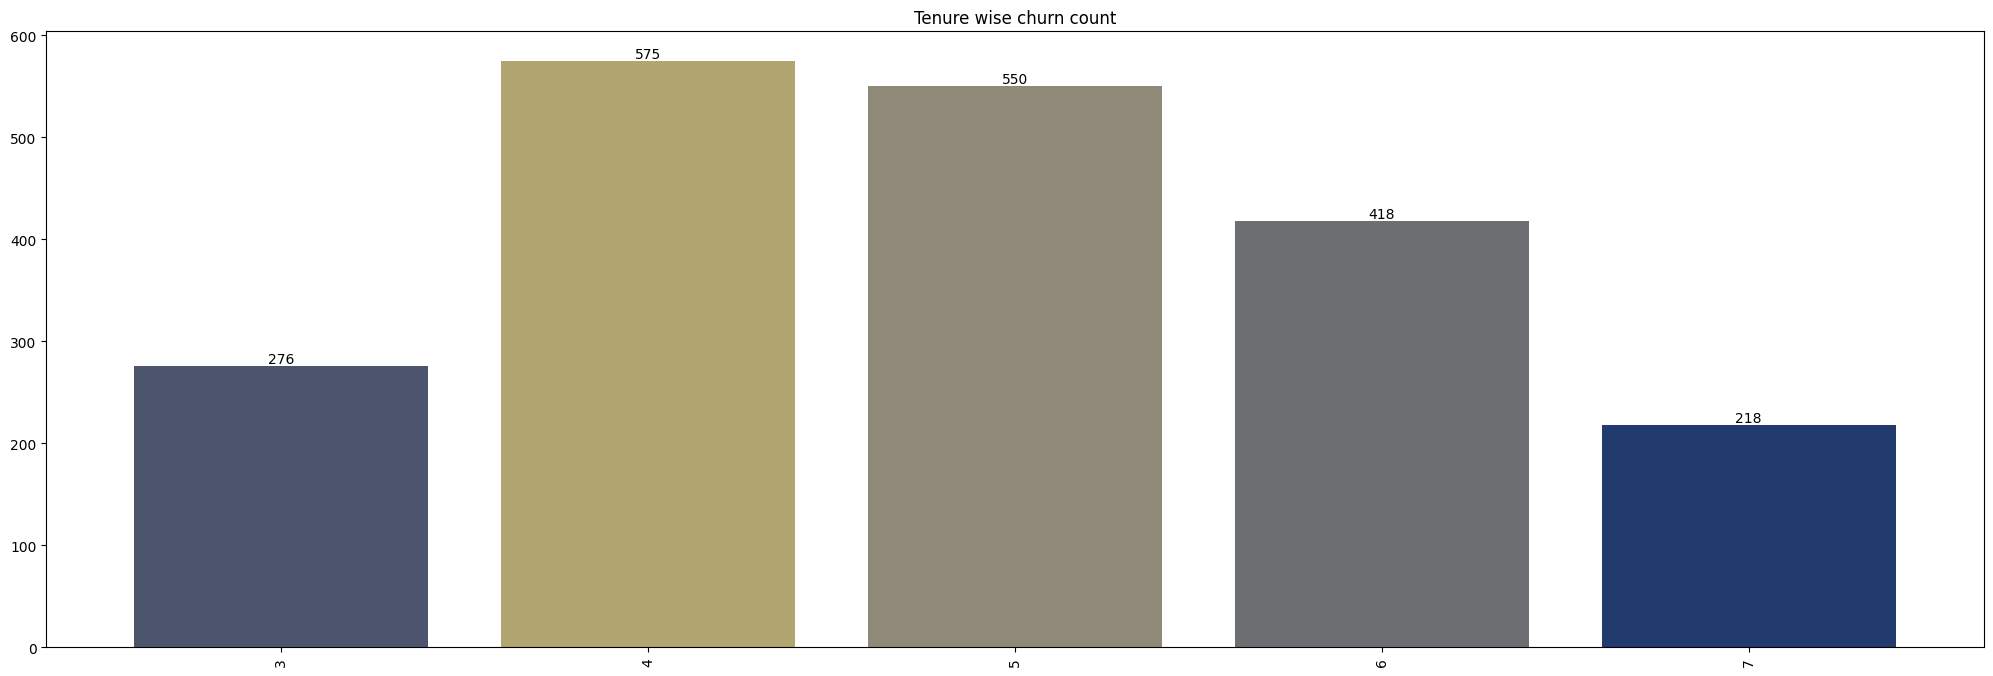

In [85]:
#Step 3.20: Show Tenure Wise Churn Analysis
plt.figure(figsize=(25,8))
plt.title("Tenure wise churn count")
temp_df= final_df.groupby('Tenure')['Exited'].sum().sort_values()
x= temp_df.index
y= temp_df.values
ax =plt.bar(x, y , color = sns.color_palette('cividis'))
plt.bar_label(ax)
plt.xticks(rotation=90)
plt.show()



In [75]:
final_df.sample()


,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
1297,15793247,498,1,1,34,5,0.0,2,1,1,91711.66,0,2018-05-24,Hancock,France,Male,May,Thursday


In [76]:
#Step 3.21: Remove unwanted columns for Ml model
ml_drop_columns=['CustomerId','GeographyID','GenderID','Bank DOJ','Day','Surname']
ml_df= final_df.drop(ml_drop_columns, axis=1, inplace= False)
ml_df.sample()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
7129,850,33,4,100476.46,2,1,1,136539.13,0,Spain,Male,July


#Step 4: Feature Engineering
- ML only works with numerical data ,if we are getting anf textual data
- We need to convert textual data to numerical
- Technique is called Feature Engineering
- Here GeograpghyLocation, GenderCategory or Month textual in nature

In [77]:
# Types of technique:
# OHE: one hot encoding
# map: using dict
# apply lambda method
# categorical encoding
# get dummies
# ordinal encoding
# TF-IDF
# BOW: bag of words
# advance: countvectorizer, word embeddings
# more advance: vector database using cosine technique

In [78]:
#step 4.1
import calendar
months_name= list(calendar.month_name)[1:]
index = list(range(len(months_name)))
map=dict(zip(months_name,index))
ml_df['Month']=ml_df['Month'].map(map)
ml_df.sample()
#zip: bind two object together and give dict
#.map: method to map the key with value
# run only once

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
8256,671,58,4,178713.98,1,1,1,21768.21,0,Spain,Male,8


In [79]:
ml_df['GenderCategory']= ml_df['GenderCategory'].map({'Male':1,'Female':0})
ml_df['GeographyLocation']= ml_df['GeographyLocation'].map({'Germany':2,'Spain':1,'France':0})

ml_df.sample()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
6868,462,39,4,140133.08,2,0,0,131304.45,0,0,1,8


In [80]:
#Step 4.2 : Show target VS feature corr
ml_df.corr()['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.285323
GeographyLocation,0.153771
Balance,0.118533
EstimatedSalary,0.012097
Month,0.002312
Tenure,0.000699
HasCrCard,-0.007138
CreditScore,-0.027094
NumOfProducts,-0.047820


# Step 5: Divide Data into Feature VS Target

In [ ]:
x = ml_df.drop('Exited', axis = 1)
y = ml_df['Exited']
#x must be capital in dataframe
#y must be small in series
print(x.shape)
print(y.shape)

#Step 6: Divide the data into train and test

In [81]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, test_size=0.2)
print("x_train-shape",x_train.shape)
print("x_test-shape",x_test.shape)
print("y_train-shape",y_train.shape)
print("y_test-shape",y_test.shape)

x_train-shape (5,)
x_test-shape (2,)
y_train-shape (5,)
y_test-shape (2,)


# Step 7: To be Continue....
